# Import

In [2]:
from math import inf
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tikzplotlib


# Results directory

In [3]:
RESULTS_DIR = Path("results/time_per_it_6")

# File

In [4]:
DATA = RESULTS_DIR / "compromise_results.csv"
COLLECTIVE = RESULTS_DIR / "collective_results.csv"
PATH = RESULTS_DIR / "path_results.csv"

# Read files

In [5]:
df = pd.read_csv(DATA)
df_collective = pd.read_csv(COLLECTIVE)
df_path = pd.read_csv(PATH)

In [6]:
# df_bis = pd.read_csv(Path("results/time_per_it_4") / "compromise_results.csv")

In [7]:
df

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Mie_config,Mie_id,Mc_id,Nb_Mcp,Path,P_id,Compromise,Time,It,Changes
0,3,100,2,1,2,2,0,2,10,True,...,NaN,2,2,1,False,2,True,0.393154,1,0
1,3,100,4,1,4,2,0,4,10,True,...,NaN,4,4,1,False,4,True,0.383341,1,2
2,3,100,0,1,0,2,0,0,10,True,...,NaN,0,0,1,False,0,True,0.415330,1,2
3,3,100,3,1,3,2,0,3,10,True,...,NaN,3,3,1,False,3,True,0.437678,1,1
4,3,100,1,1,1,2,0,1,10,True,...,NaN,1,1,1,False,1,True,0.399783,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1602,5,100,8,2,8,6,0,8,20,True,...,NaN,8,8,1,False,8,True,303.359782,1,22
1603,5,100,7,2,7,6,0,7,20,True,...,NaN,7,7,1,False,7,True,302.475094,1,15
1604,5,100,0,2,0,6,0,0,10,True,...,NaN,0,0,1,True,0,True,388.843072,1,5
1605,5,100,0,2,0,6,0,0,10,True,...,NaN,0,0,1,False,0,True,603.165768,2,3


In [8]:
df_collective

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Mie_config,Mie_id,Mc_id,Nb_Mcp,Path,P_id,It,Time,Objective,Optimal
0,3,100,4,1,4,2,0,4,10,True,...,NaN,4,4,1,False,4,0,0.163580,1.0,True
1,3,100,2,1,2,2,0,2,10,True,...,NaN,2,2,1,False,2,0,0.173221,0.0,True
2,3,100,2,1,2,2,0,2,10,True,...,NaN,2,2,1,True,2,0,0.187768,0.0,True
3,3,100,1,1,1,2,0,1,10,True,...,NaN,1,1,1,False,1,0,0.177852,1.0,True
4,3,100,3,1,3,2,0,3,10,True,...,NaN,3,3,1,True,3,0,0.206693,1.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3103,5,100,2,2,2,6,0,2,30,True,...,NaN,2,2,1,False,2,0,301.640931,8.0,False
3104,5,100,3,2,3,6,0,3,30,True,...,NaN,3,3,1,True,3,0,301.385806,4.0,False
3105,5,100,1,2,1,4,0,1,20,True,...,NaN,1,1,1,True,1,2,301.023235,1.0,False
3106,5,100,3,2,3,6,0,3,30,True,...,NaN,3,3,1,False,3,0,301.658470,4.0,False


In [9]:
df_path

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Mc_id,Nb_Mcp,Path,P_id,It,Dm_id,Time,Length,Model_Length,Found
0,3,100,1,1,1,2,0,1,10,True,...,1,1,True,1,0,0,0.000003,1,2,True
1,3,100,2,1,2,2,0,2,10,True,...,2,1,True,2,0,1,0.000004,0,2,True
2,3,100,1,1,1,2,0,1,10,True,...,1,1,True,1,0,1,0.000005,1,2,True
3,3,100,0,1,0,2,0,0,10,True,...,0,1,True,0,0,1,0.000005,1,2,True
4,3,100,0,1,0,2,0,0,10,True,...,0,1,True,0,0,0,0.698444,1,3,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6318,5,100,3,2,3,6,0,3,30,True,...,3,1,True,3,0,5,0.517039,4,6,True
6319,5,100,1,2,1,4,0,1,20,True,...,1,1,True,1,2,1,0.254211,1,3,True
6320,5,100,1,2,1,4,0,1,20,True,...,1,1,True,1,2,2,0.246402,1,3,True
6321,5,100,3,2,3,6,0,3,30,True,...,3,1,True,3,0,4,0.387958,2,5,True


# New attributes

In [10]:
df["Gen"] = np.array(["Homogene", "Heterogene"])[df["Group"] % 2]
df["Accept"] = np.array(["Conservative", "Tolerant"])[df["Group"] % 2]

df["Changes_Prop"] = df["Changes"] / (df["N_bc"] * df["Group_size"])

df_collective["Objective_Prop"] = df_collective["Objective"] / df_collective["N_bc"]

In [11]:
# from math import inf


# df_collective.loc[df_collective["Objective"] == inf, "Time"] = 600

# Filter

In [12]:
# dff = df[df["Fitness_train"] == 1]
# dff = df[df["N_tr"].isin([10, 20, 30, 80, 90, 100])]
# dff = df[df["N_tr"] % 20 == 0]
dff = df
dff = dff[~df["Mie"]]
dff = dff.drop(columns=["Mie", "Mie_id"])
# dff = dff[dff["Group_size"] == 2]
dff = dff[dff["Ko"] <= 3]
dff = dff[dff["Gen"] == "Homogene"]
# dff = dff[dff["Path"]]
# dff = dff[dff["Compromise"]]

In [13]:
# dff.loc[dff["Time"] > 300, "Compromise"] = False

In [14]:
dff

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Nb_Mcp,Path,P_id,Compromise,Time,It,Changes,Gen,Accept,Changes_Prop
0,3,100,2,1,2,2,0,2,10,True,...,1,False,2,True,0.393154,1,0,Homogene,Conservative,0.000000
1,3,100,4,1,4,2,0,4,10,True,...,1,False,4,True,0.383341,1,2,Homogene,Conservative,0.100000
2,3,100,0,1,0,2,0,0,10,True,...,1,False,0,True,0.415330,1,2,Homogene,Conservative,0.100000
3,3,100,3,1,3,2,0,3,10,True,...,1,False,3,True,0.437678,1,1,Homogene,Conservative,0.050000
4,3,100,1,1,1,2,0,1,10,True,...,1,False,1,True,0.399783,1,2,Homogene,Conservative,0.100000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1602,5,100,8,2,8,6,0,8,20,True,...,1,False,8,True,303.359782,1,22,Homogene,Conservative,0.183333
1603,5,100,7,2,7,6,0,7,20,True,...,1,False,7,True,302.475094,1,15,Homogene,Conservative,0.125000
1604,5,100,0,2,0,6,0,0,10,True,...,1,True,0,True,388.843072,1,5,Homogene,Conservative,0.083333
1605,5,100,0,2,0,6,0,0,10,True,...,1,False,0,True,603.165768,2,3,Homogene,Conservative,0.050000


# Merge data

In [15]:
# df = pd.merge(
#     df_mip,
#     df_path,
#     how="left",
#     on=[
#         "M",
#         "N_tr",
#         "Atr_id",
#         "Ko",
#         "Mo_id",
#         "Group_size",
#         "Group",
#         "Mi_id",
#         "N_bc",
#         "Same_alt",
#         "D_id",
#         "Config",
#         "Mc_id",
#         "Path",
#         "P_id",
#         "It"
#     ],
#     suffixes=["_mip", "_path"],
# )


df_compromise_path = dff[dff["Path"]]
df_compromise_path = df_compromise_path[df_compromise_path["Compromise"]]
df_compromise_path_index = df_compromise_path.drop(
    columns=["Path", "Compromise", "Time", "It", "Changes", "Changes_Prop"]
)
df_compromise_no_path = dff[~dff["Path"]]
df_compromise_no_path = df_compromise_no_path[df_compromise_no_path["Compromise"]]
df_compromise_no_path_index = df_compromise_no_path.drop(
    columns=["Path", "Compromise", "Time", "It", "Changes", "Changes_Prop"]
)

df_compromise_index = pd.merge(
    df_compromise_path_index,
    df_compromise_no_path_index,
    how="inner",
    on=[
        "M",
        "N_tr",
        "Atr_id",
        "Ko",
        "Mo_id",
        "Group_size",
        "Group",
        "Mi_id",
        "N_bc",
        "Same_alt",
        "D_id",
        "Config",
        "P_id",
        "Mc_id",
        "P_id",
        "Gen",
        "Accept",
    ],
)

df_compromise_path = pd.merge(
    df_compromise_path,
    df_compromise_index,
    how="inner",
    on=[
        "M",
        "N_tr",
        "Atr_id",
        "Ko",
        "Mo_id",
        "Group_size",
        "Group",
        "Mi_id",
        "N_bc",
        "Same_alt",
        "D_id",
        "Config",
        "P_id",
        "Mc_id",
        "P_id",
        "Gen",
        "Accept",
    ],
    suffixes=["", ""],
)

df_compromise_no_path = pd.merge(
    df_compromise_no_path,
    df_compromise_index,
    how="inner",
    on=[
        "M",
        "N_tr",
        "Atr_id",
        "Ko",
        "Mo_id",
        "Group_size",
        "Group",
        "Mi_id",
        "N_bc",
        "Same_alt",
        "D_id",
        "Config",
        "P_id",
        "Mc_id",
        "P_id",
        "Gen",
        "Accept",
    ],
    suffixes=["", ""],
)

# df_compromise = pd.merge(
#     df_compromise_path,
#     df_compromise_no_path,
#     how="inner",
#     on=[
#         "M",
#         "N_tr",
#         "Atr_id",
#         "Ko",
#         "Mo_id",
#         "Group_size",
#         "Group",
#         "Mi_id",
#         "N_bc",
#         "Same_alt",
#         "D_id",
#         "Config",
#         "Mie",
#         "P_id",
#         "Mie_id",
#         "Mc_id",
#         "P_id",
#         "Gen",
#         "Accept"
#     ],
#     suffixes=["_path", "_no_path"],
# )

df_compromise = pd.concat([df_compromise_path, df_compromise_no_path])

df_compromise

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Changes,Gen,Accept,Changes_Prop,Method_x,Mie_config_x,Nb_Mcp_x,Method_y,Mie_config_y,Nb_Mcp_y
0,3,100,3,1,3,2,0,3,10,True,...,1,Homogene,Conservative,0.050000,mip,NaN,1,mip,NaN,1
1,3,100,2,1,2,2,0,2,10,True,...,0,Homogene,Conservative,0.000000,mip,NaN,1,mip,NaN,1
2,3,100,4,1,4,2,0,4,10,True,...,2,Homogene,Conservative,0.100000,mip,NaN,1,mip,NaN,1
3,3,100,8,1,8,2,0,8,10,True,...,0,Homogene,Conservative,0.000000,mip,NaN,1,mip,NaN,1
4,3,100,9,1,9,2,0,9,10,True,...,0,Homogene,Conservative,0.000000,mip,NaN,1,mip,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,5,100,4,2,4,6,0,4,10,True,...,0,Homogene,Conservative,0.000000,mip,NaN,1,mip,NaN,1
696,5,100,3,2,3,6,0,3,20,True,...,7,Homogene,Conservative,0.058333,mip,NaN,1,mip,NaN,1
697,5,100,7,2,7,6,0,7,10,True,...,0,Homogene,Conservative,0.000000,mip,NaN,1,mip,NaN,1
698,5,100,9,2,9,6,0,9,10,True,...,0,Homogene,Conservative,0.000000,mip,NaN,1,mip,NaN,1


# Plot

**Est-ce que le processus fait converger les DMs vers un modèle collectif accepté à l'unanimité ?**

Oui, seules quelques instances (7) n'ont pas eu le temps de converger dans la limite de 1h maximum, car il y a eu plusieurs itérations (+ de 12, donc avec 5mn par itérations).

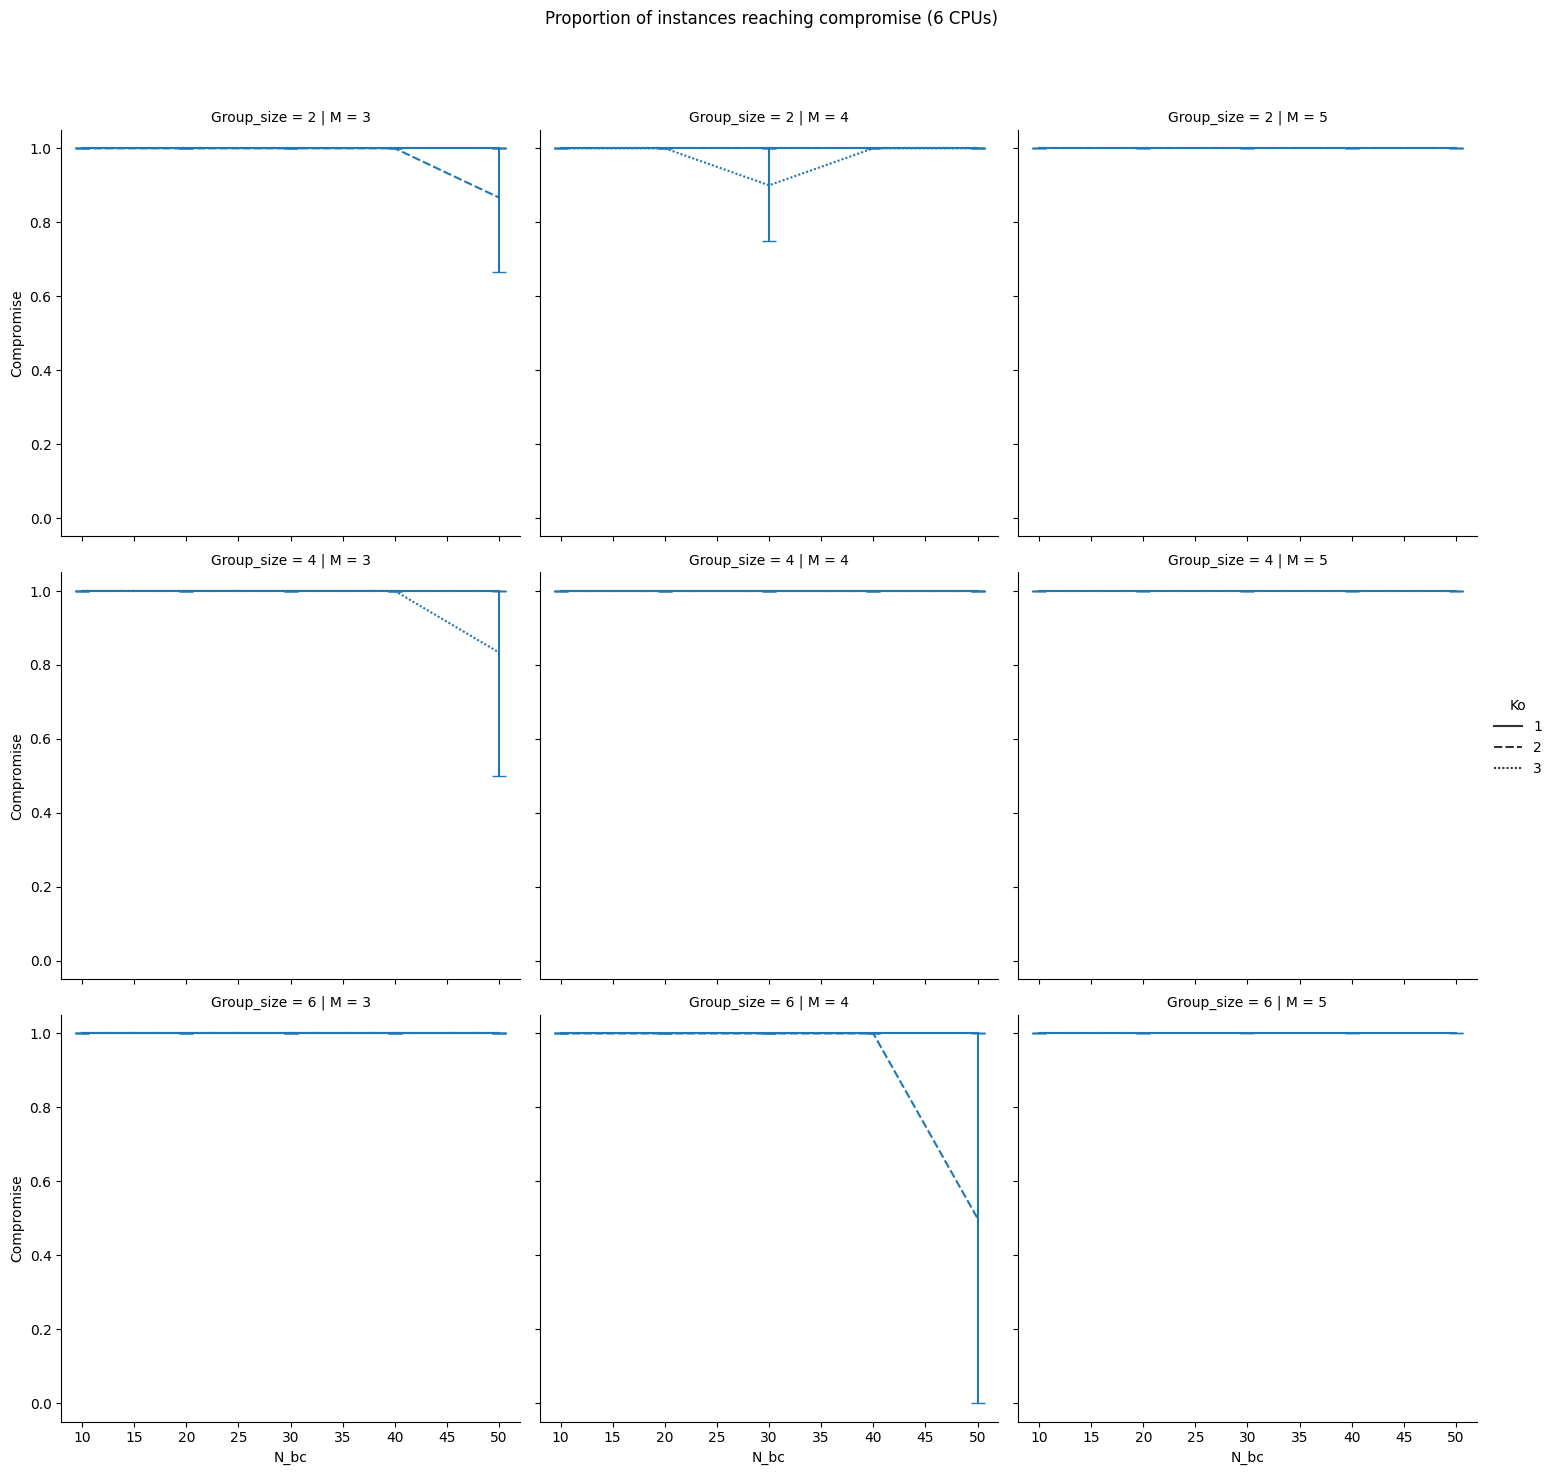

In [16]:
g = sns.relplot(
    dff,
    x="N_bc",
    y="Compromise",
    row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Proportion of instances reaching compromise (6 CPUs)")
g

**A quel point les DMs doivent modifier leurs préférences pour converger vers le modèle collectif final ?**

Ils doivent modifier au maximum 10% des comparisons représentant leurs préférences au départ. Cette proportion diminue avec un nombre de profils de référence plus élevé, car le modèle collectif a plus de paramètres, donc peut être plus précis et parcimonieux sur les comparaisons à changer.
Le DM devant modifier le plus de comparaisons doit modifier au maximum 30% de celles données en entrée.

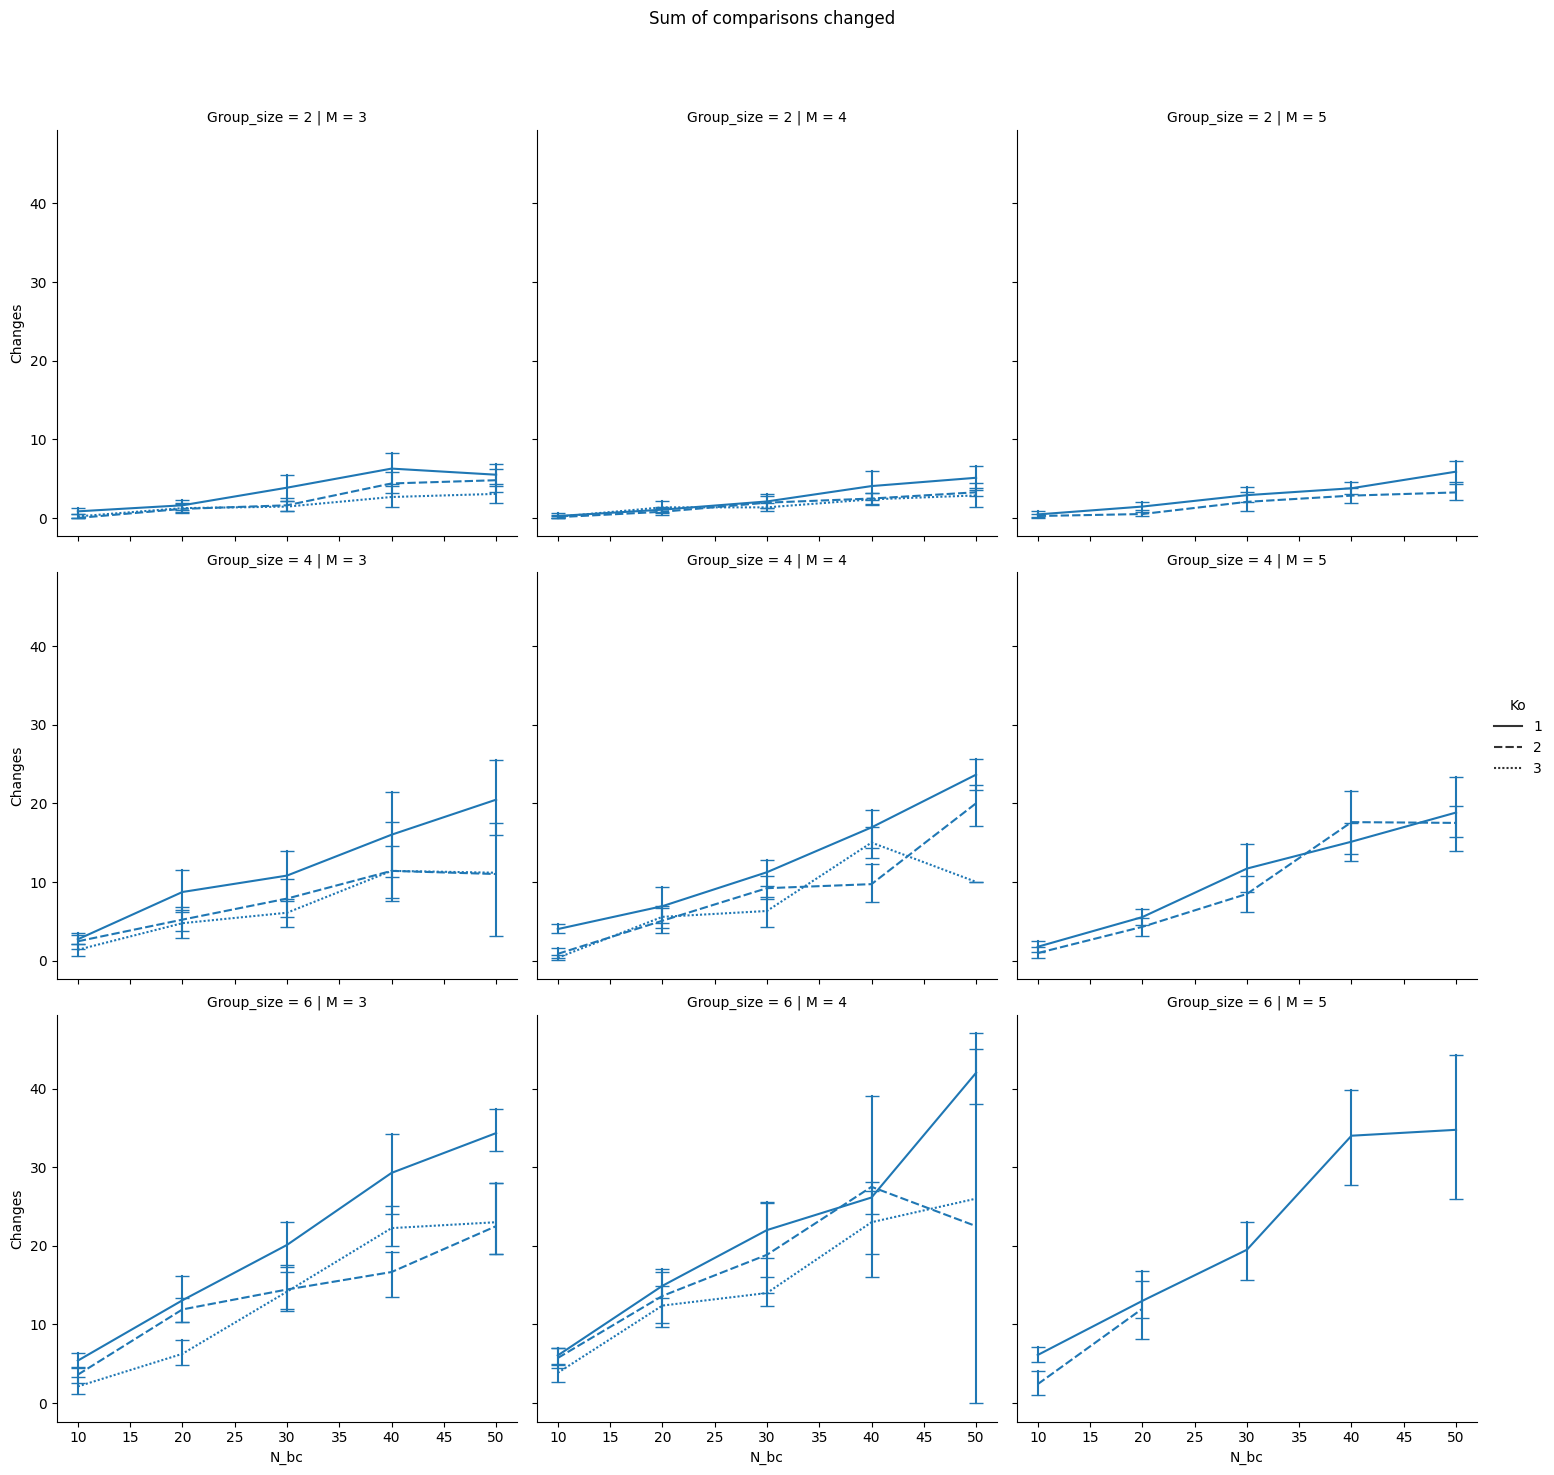

In [17]:
g = sns.relplot(
    dff,
    x="N_bc",
    y="Changes",
    row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Sum of comparisons changed")
g

**A quel point les DMs doivent modifier leurs préférences pour converger vers le modèle collectif final ?**

Ils doivent modifier au maximum 10% des comparisons représentant leurs préférences au départ. Cette proportion diminue avec un nombre de profils de référence plus élevé, car le modèle collectif a plus de paramètres, donc peut être plus précis et parcimonieux sur les comparaisons à changer.
Le DM devant modifier le plus de comparaisons doit modifier au maximum 30% de celles données en entrée.

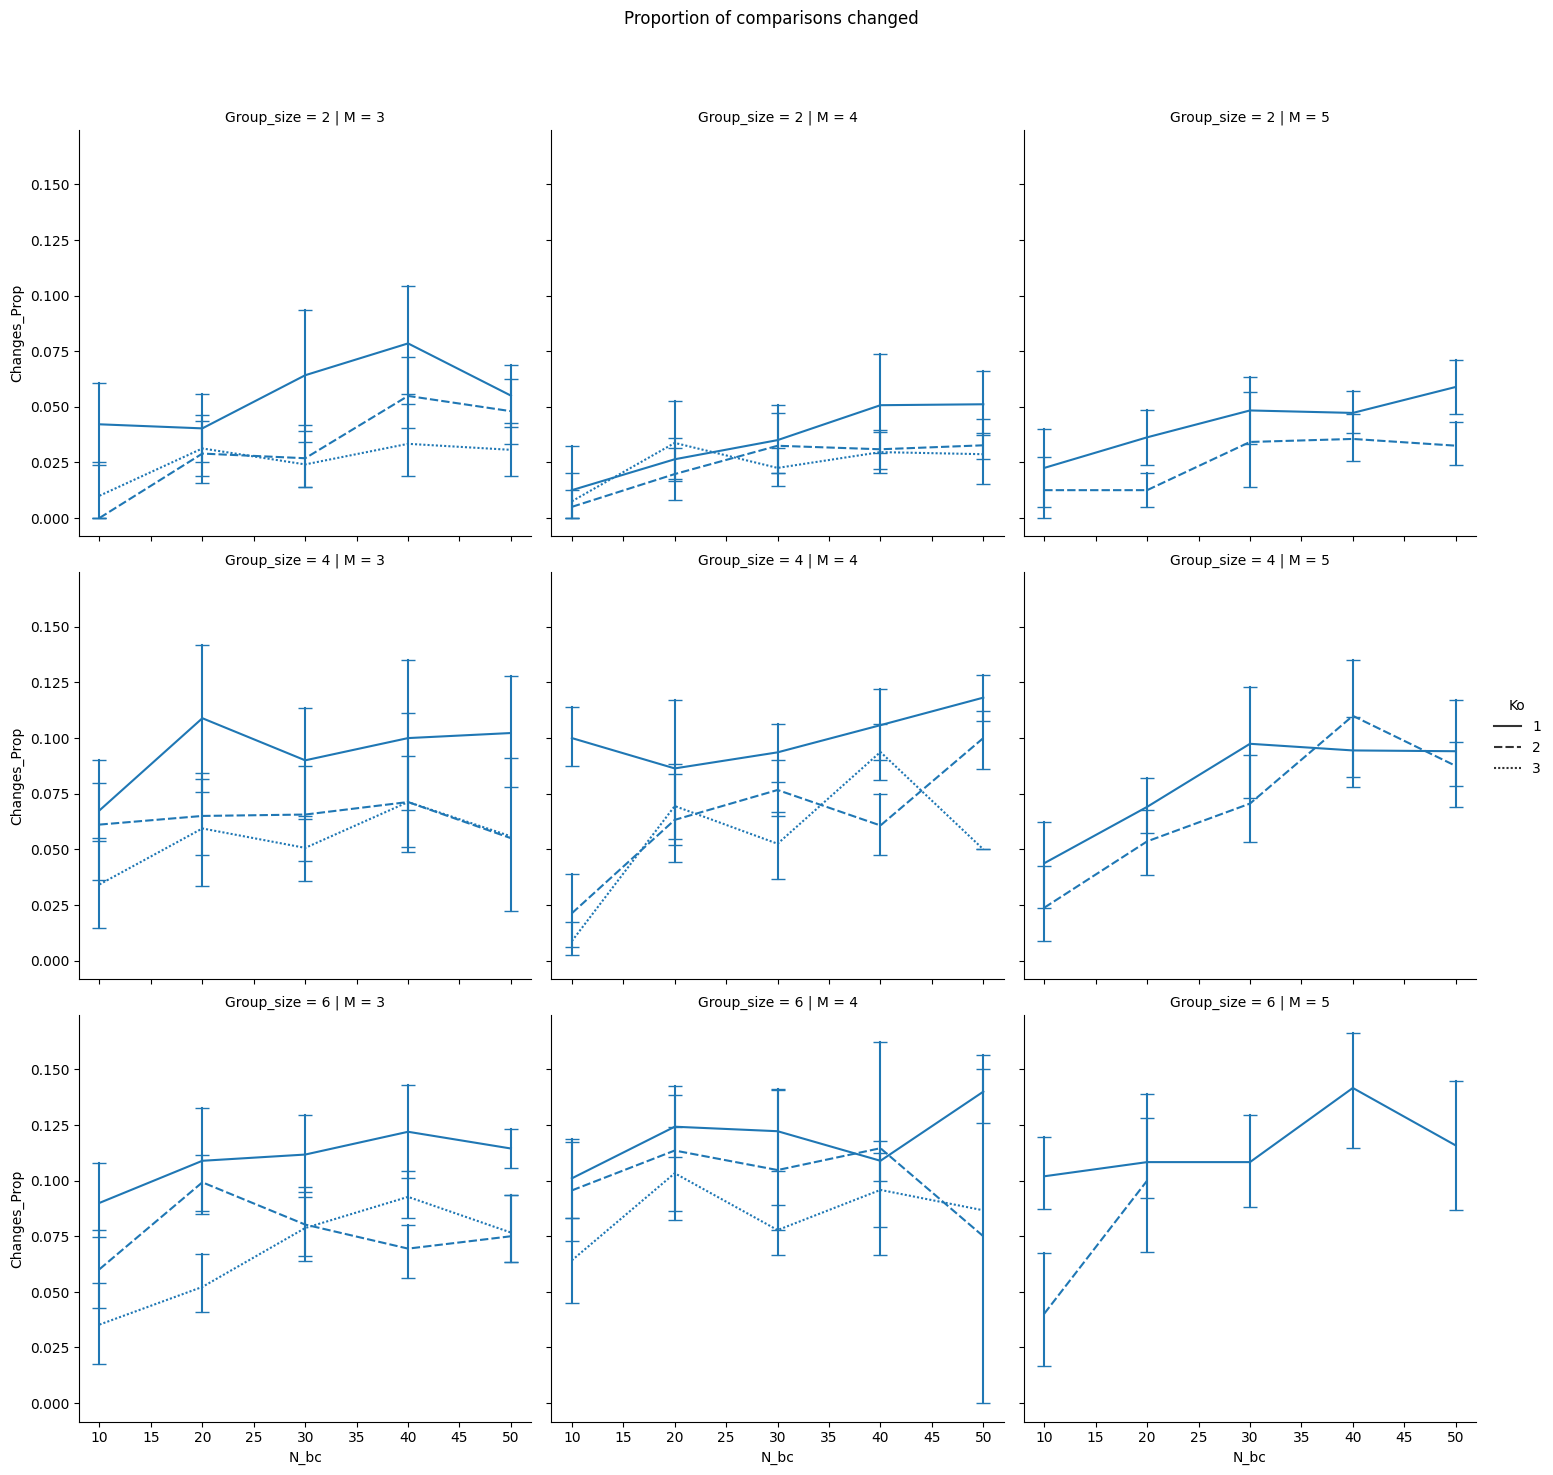

In [18]:
g = sns.relplot(
    dff,
    x="N_bc",
    y="Changes_Prop",
    row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Proportion of comparisons changed")
g

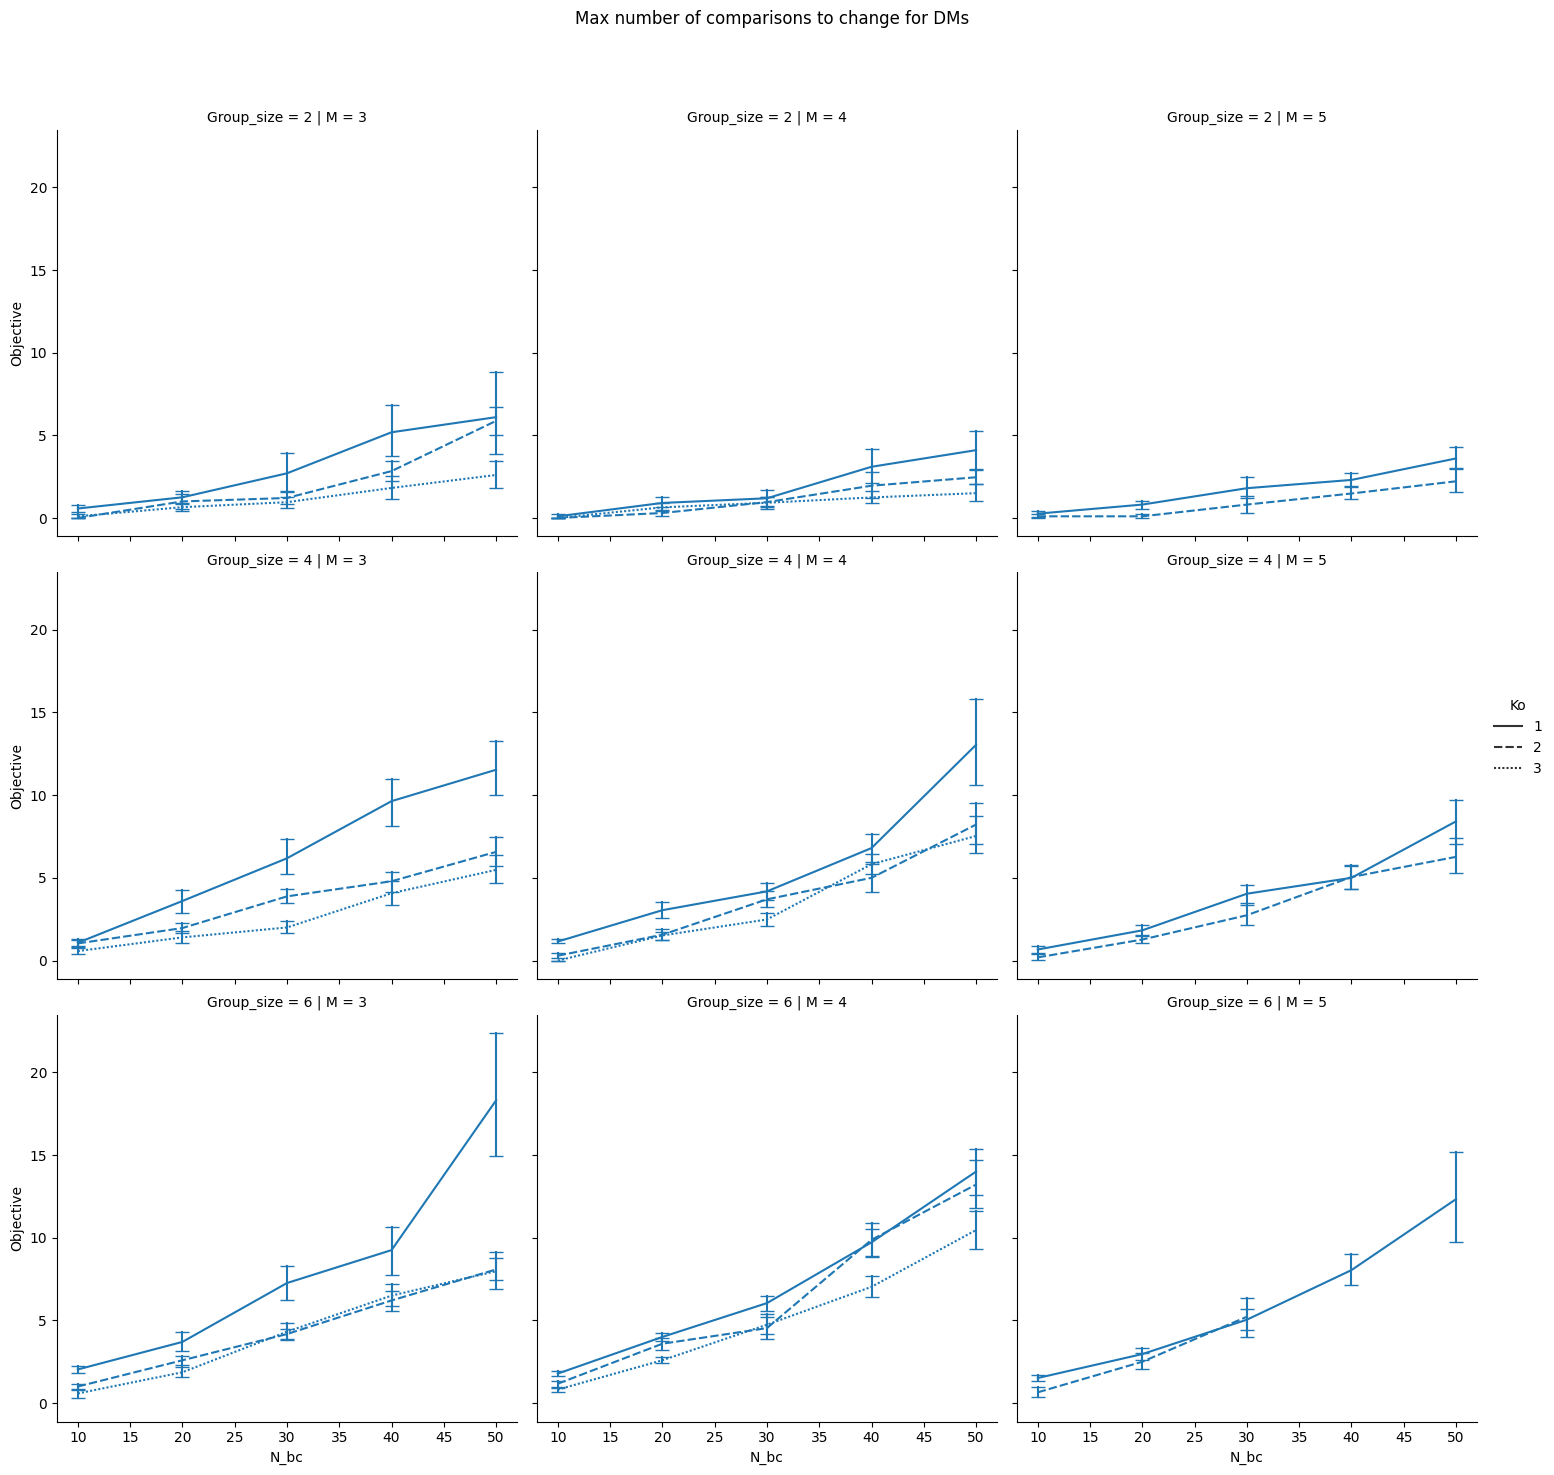

In [19]:
g = sns.relplot(
    df_collective,
    x="N_bc",
    y="Objective",
    row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Max number of comparisons to change for DMs")
g

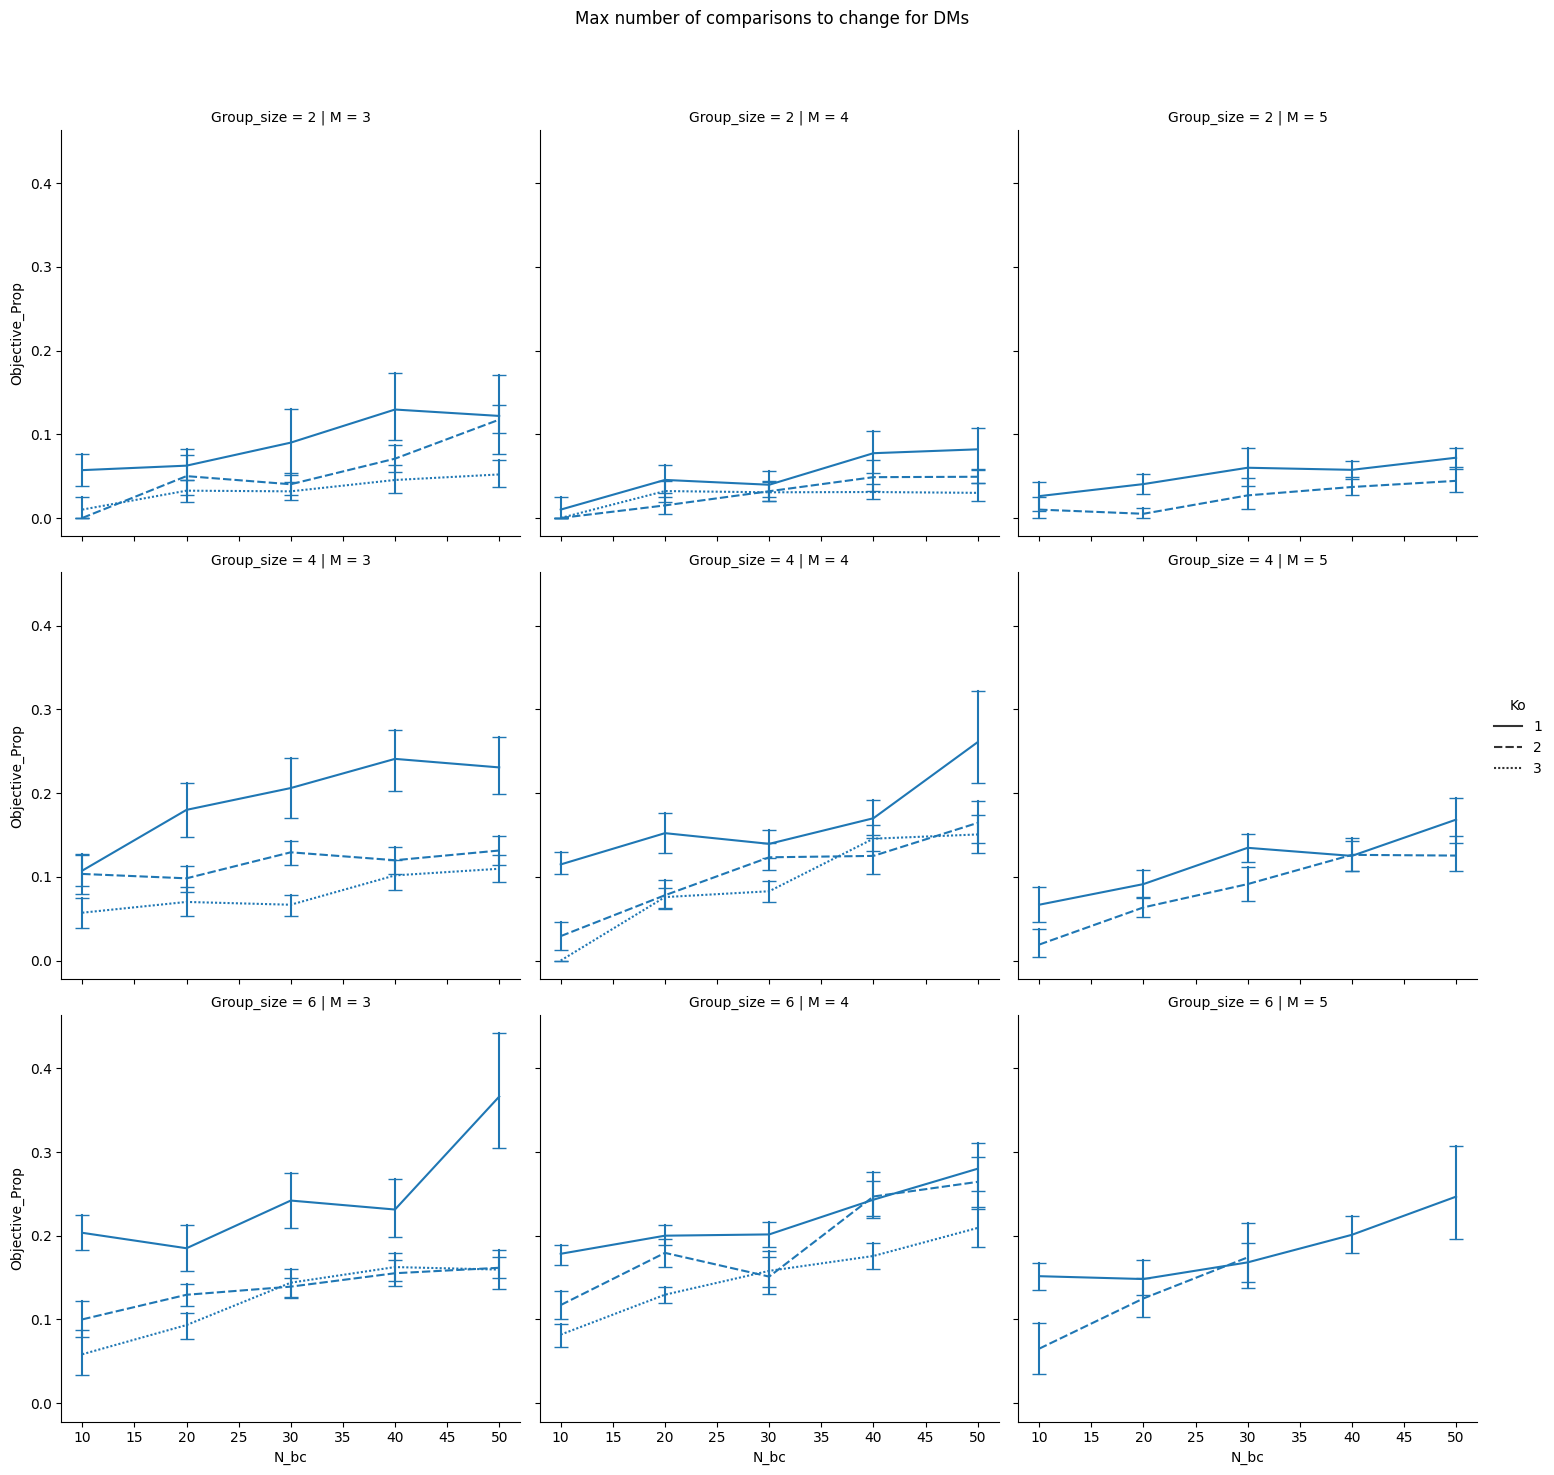

In [20]:
g = sns.relplot(
    df_collective,
    x="N_bc",
    y="Objective_Prop",
    row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Max number of comparisons to change for DMs")
g

**Ce nombre de paires à changer est-il optimal ?**

Pour la plupart des instances, l'optimalité n'est pas atteinte par le MILP, hormis pour les instances les plus petites (faible nombre de paires de comparisons, 1 seul profil de référence)
Cependant, des tests menés plus qualitativement sur quelques instances montrent que les solutions faisables trouvées sont à l'optimum (ou très proche), mais la preuve d'optimalité met du temps à être atteinte.

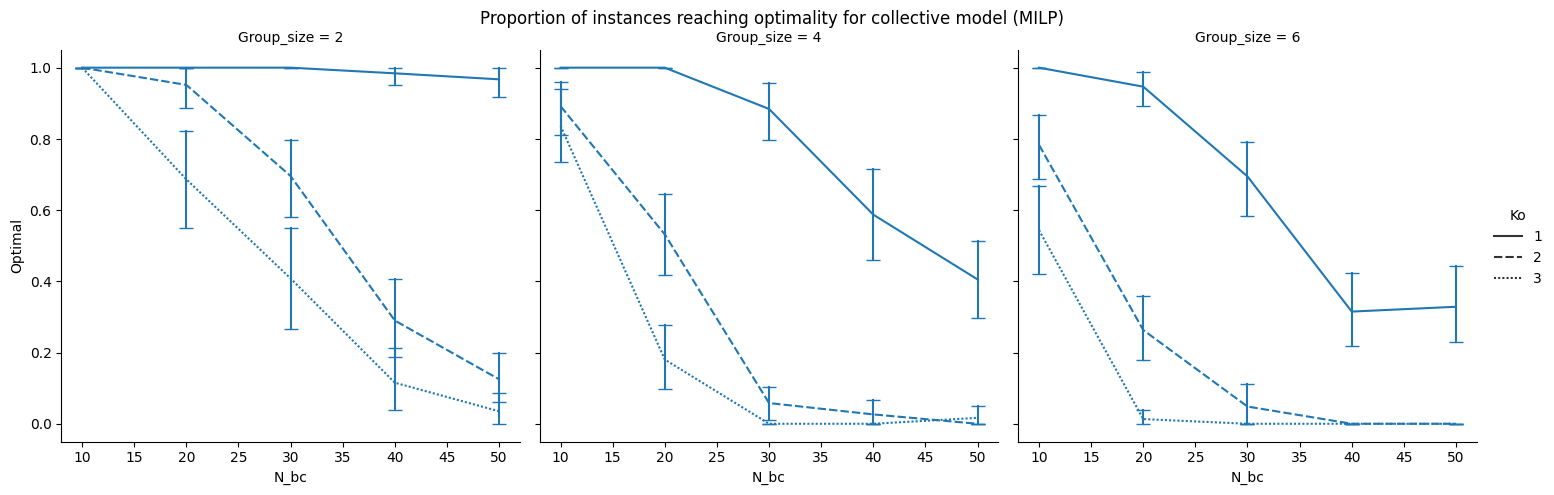

In [21]:
g = sns.relplot(
    df_collective,
    x="N_bc",
    y=df_collective["Optimal"],
    col="Group_size",
    # col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Proportion of instances reaching optimality for collective model (MILP)")
g

**Combien de temps cela prend-il ?**

Les instances testées mettent moins de 10 minutes pour converger, temps qui dépend fortement du nombre de paires de comparisons données par décideurs, ainsi que du nombre de profils de références.
Ce temps dépend en grande partie de la résolution du MILP (qui n'atteint pas souvent pas l'optimum), même si le calcul des chemins de préférences peut mettre 1 à 2 minutes pour certaines grandes instances.

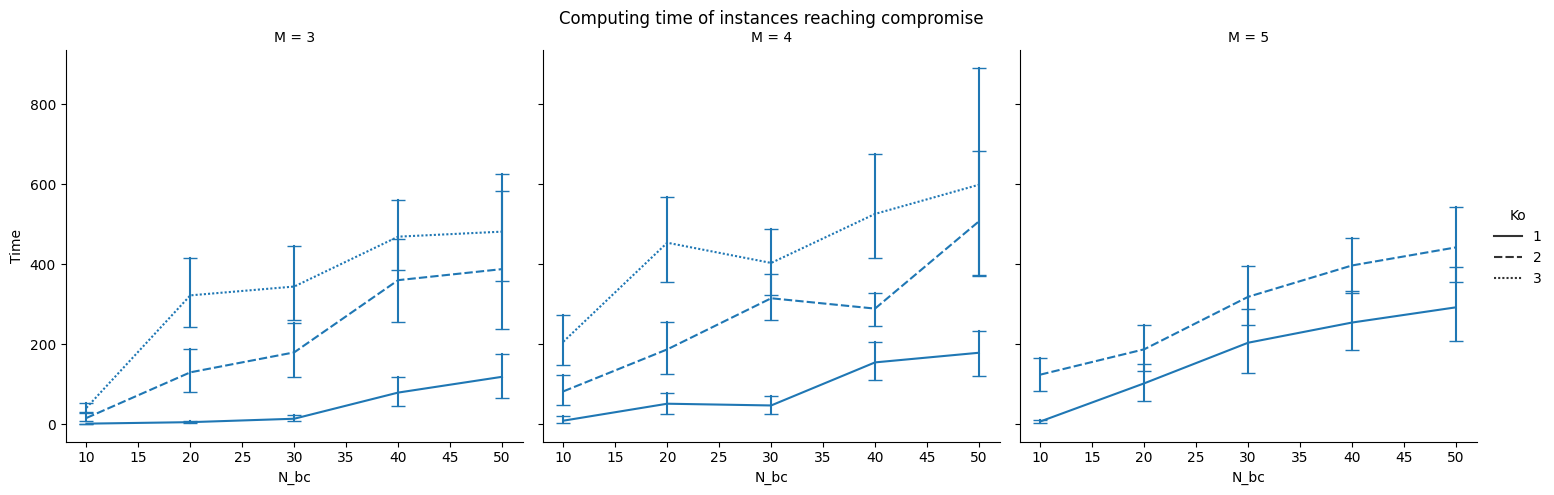

In [22]:
g = sns.relplot(
    dff[dff["Compromise"]],
    x="N_bc",
    y="Time",
    # row="Ko",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Computing time of instances reaching compromise")
g

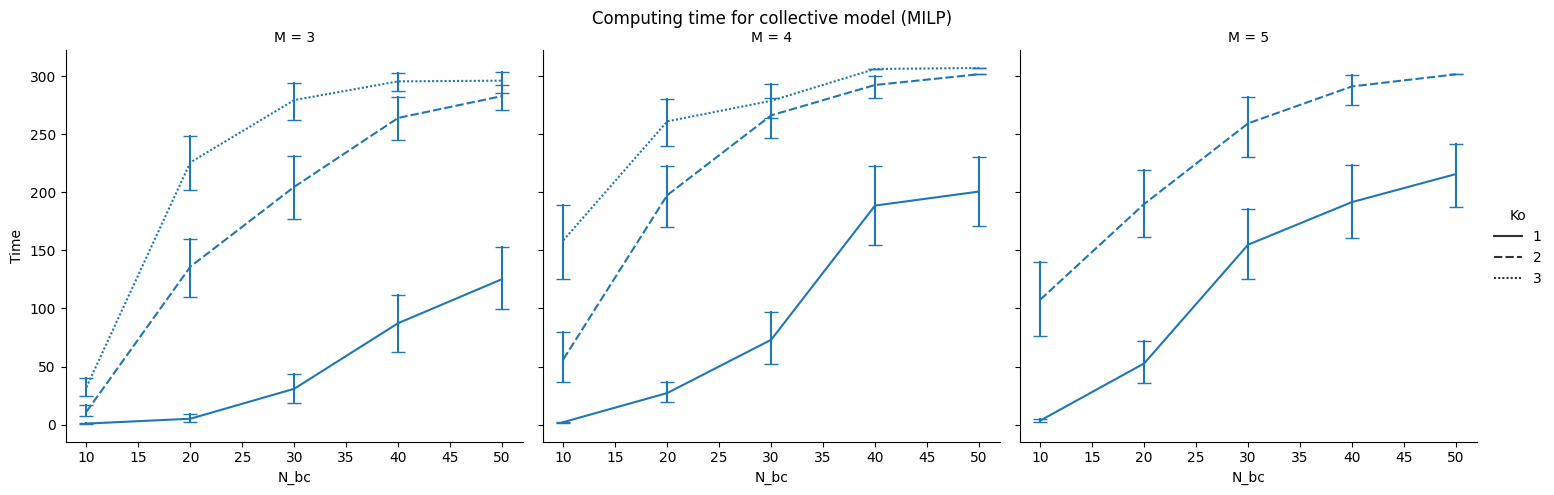

In [23]:
g = sns.relplot(
    df_collective,
    x="N_bc",
    y="Time",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Computing time for collective model (MILP)")
g

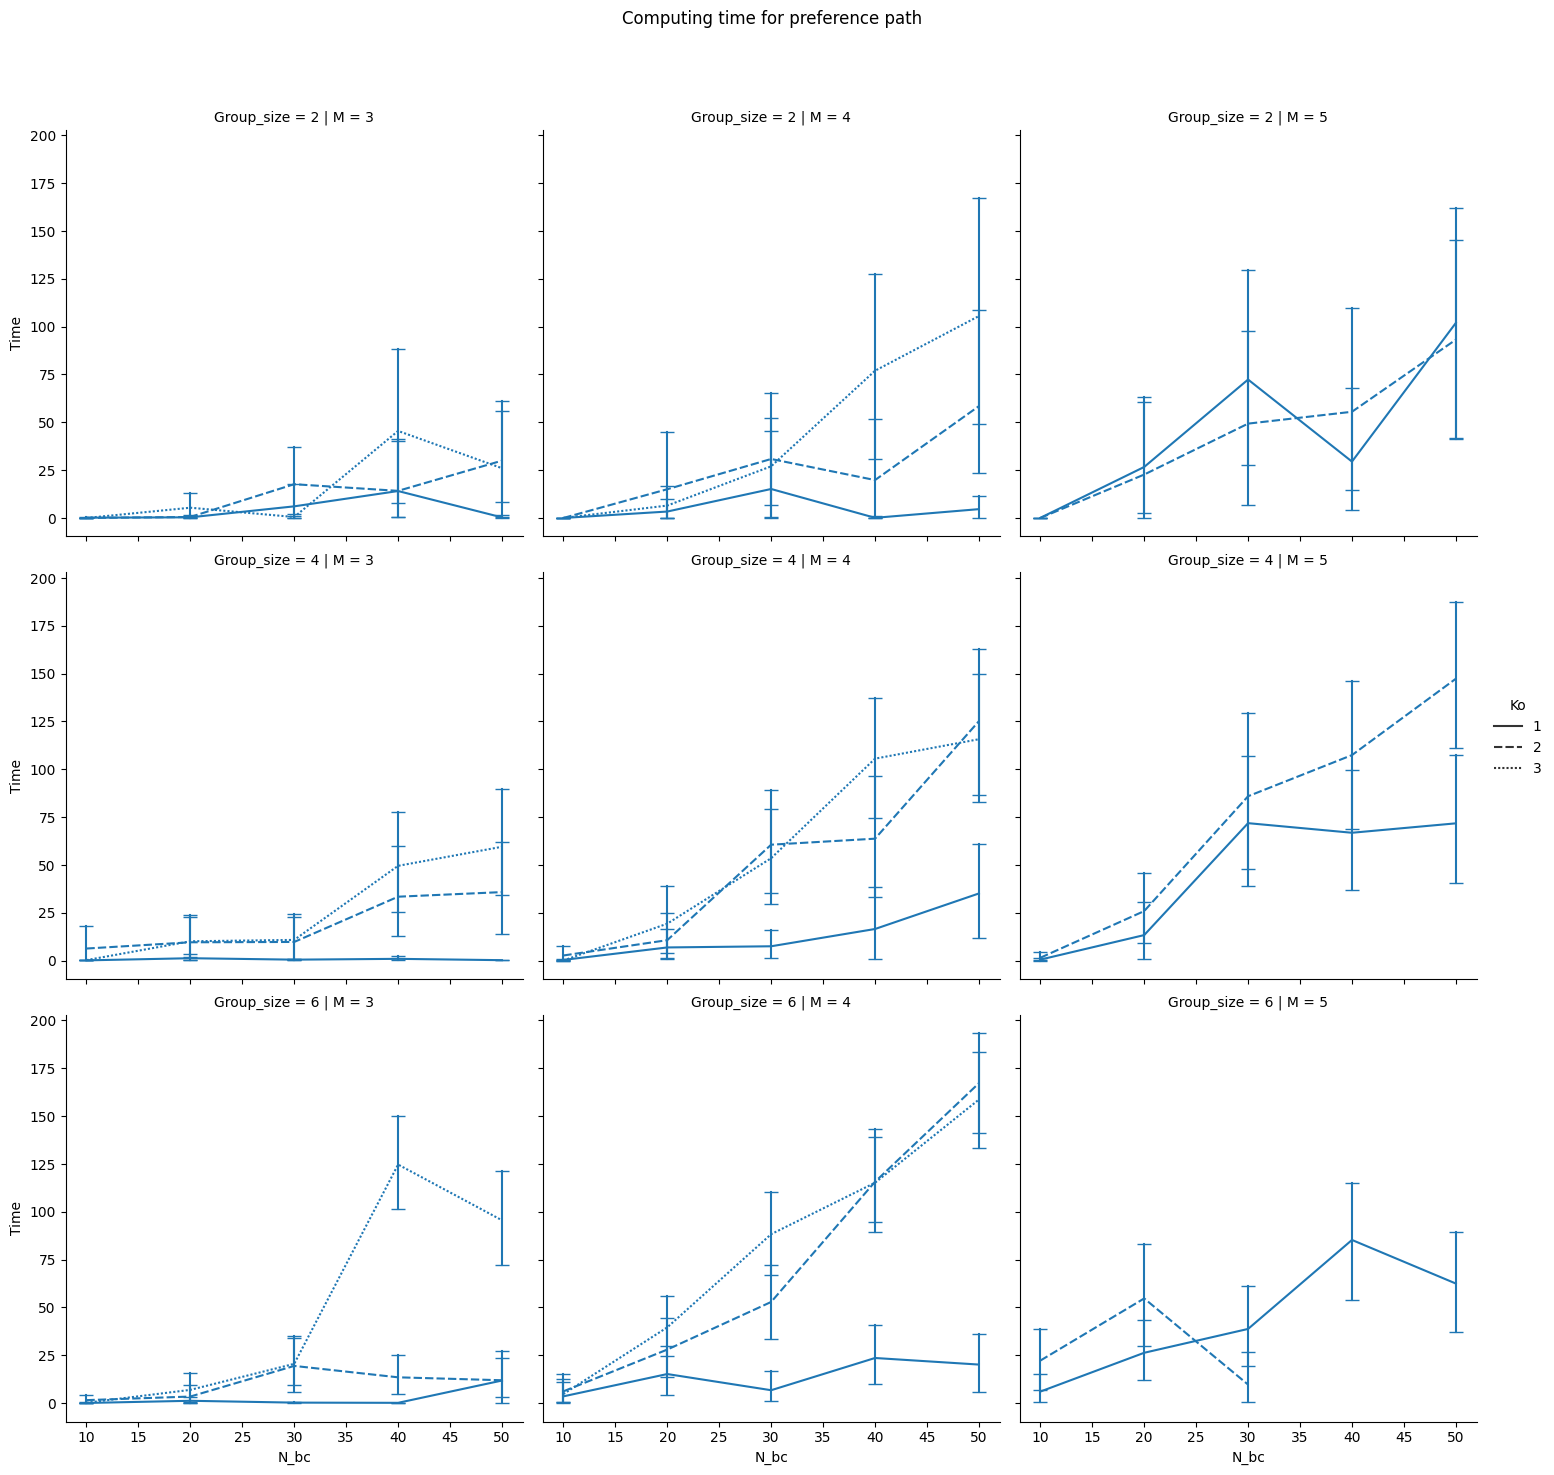

In [24]:
g = sns.relplot(
    df_path,
    x="N_bc",
    y="Time",
    row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Computing time for preference path")
g

**Y a-t-il plusieurs interactions avec les DMs, et donc des moments de pauses ?**

Le nombre d'itérations est, sauf cas rare, inférieur à 2 pour les instances testées (DMs proches entre eux).

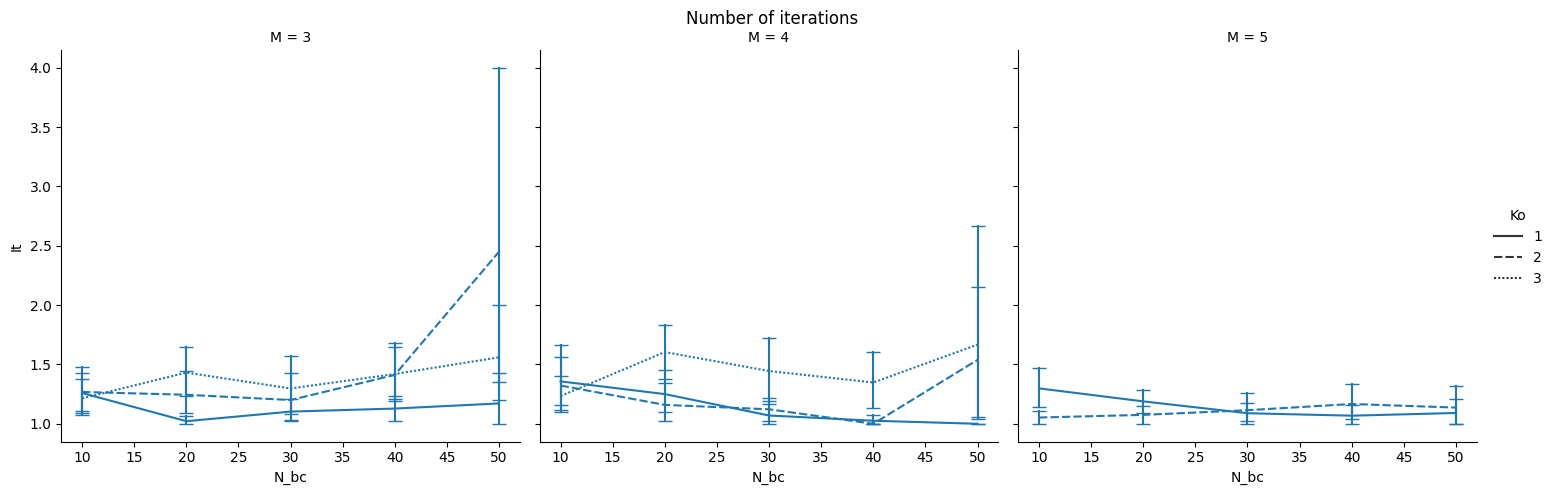

In [25]:
g = sns.relplot(
    dff,
    x="N_bc",
    y="It",
    # row="Ko",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Number of iterations")
g

**Est-ce que les chemins de préférence apportent une plus-value ?**

Non, ou du moins pas sur les métriques du dessus.

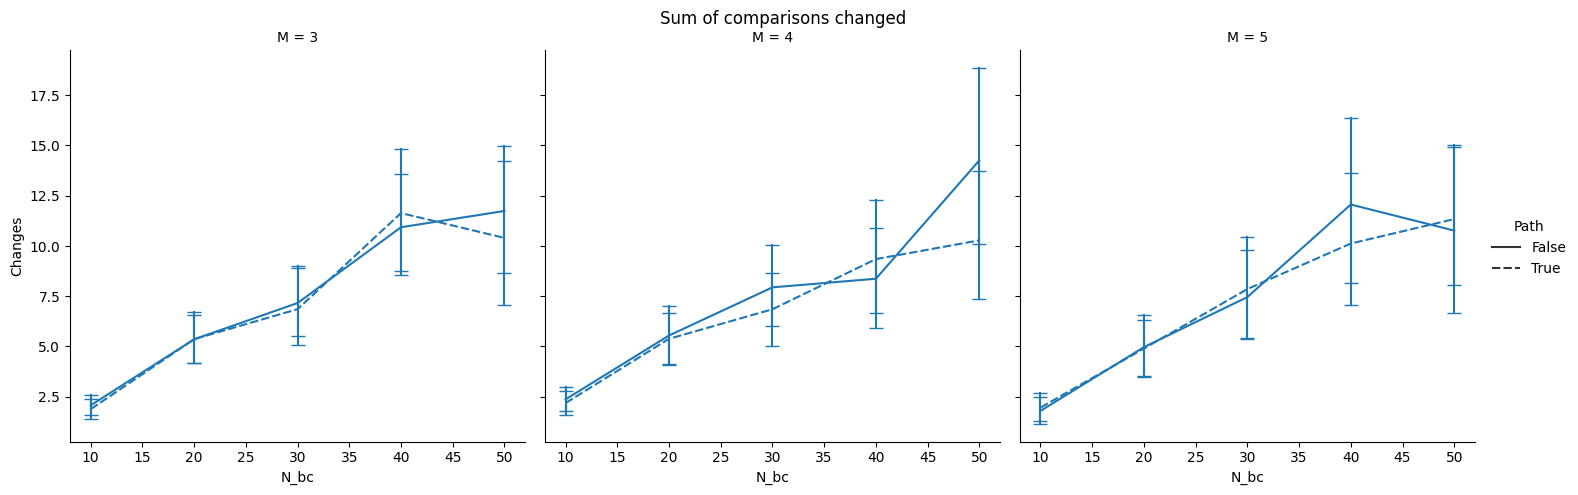

In [26]:
g = sns.relplot(
    dff,
    x="N_bc",
    y="Changes",
    # row="Group_size",
    col="M",
    style="Path",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Sum of comparisons changed")
g

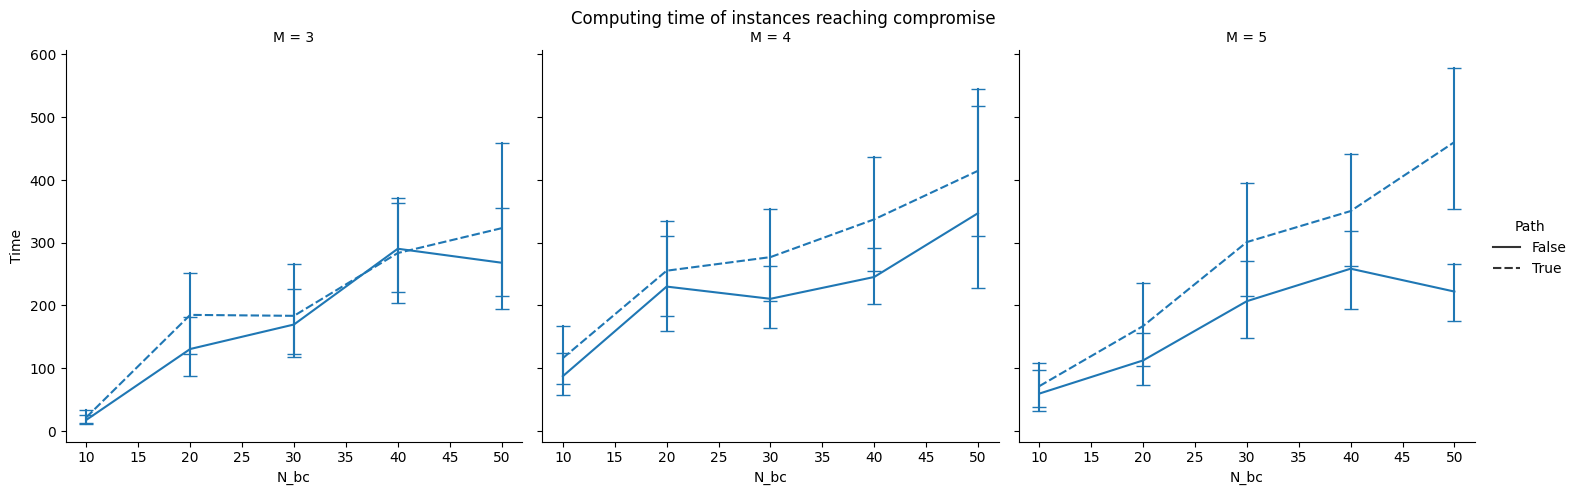

In [27]:
g = sns.relplot(
    dff[dff["Compromise"]],
    x="N_bc",
    y="Time",
    # row="Ko",
    col="M",
    style="Path",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Computing time of instances reaching compromise")
g

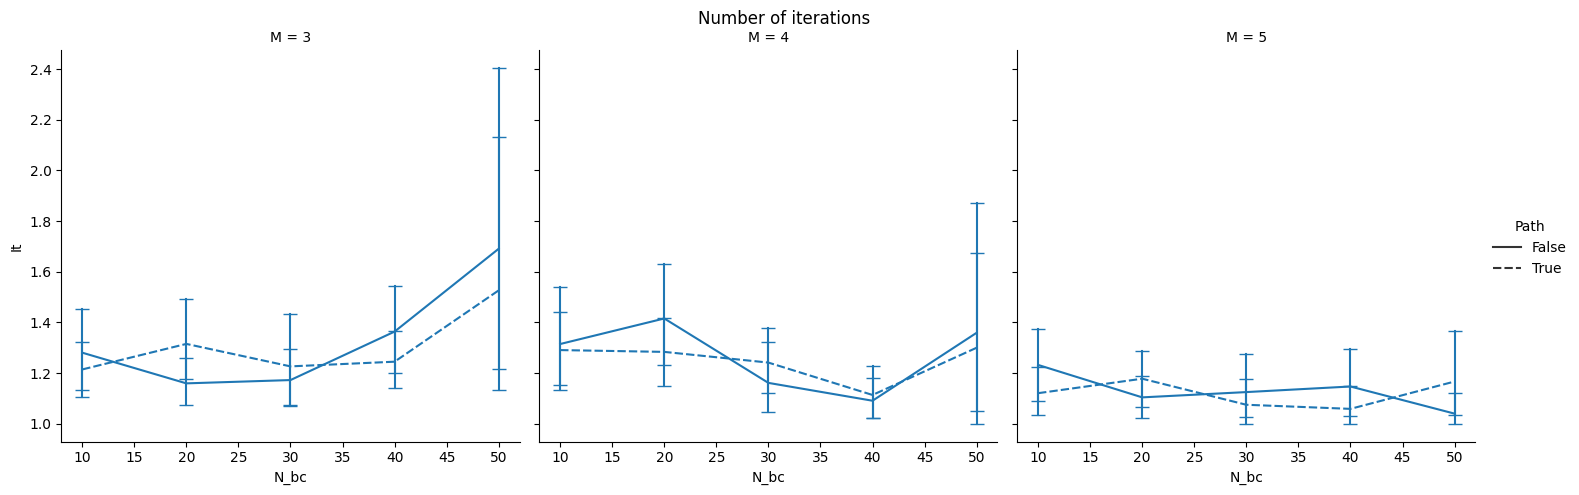

In [28]:
g = sns.relplot(
    dff,
    x="N_bc",
    y="It",
    # row="Ko",
    col="M",
    style="Path",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Number of iterations")
g

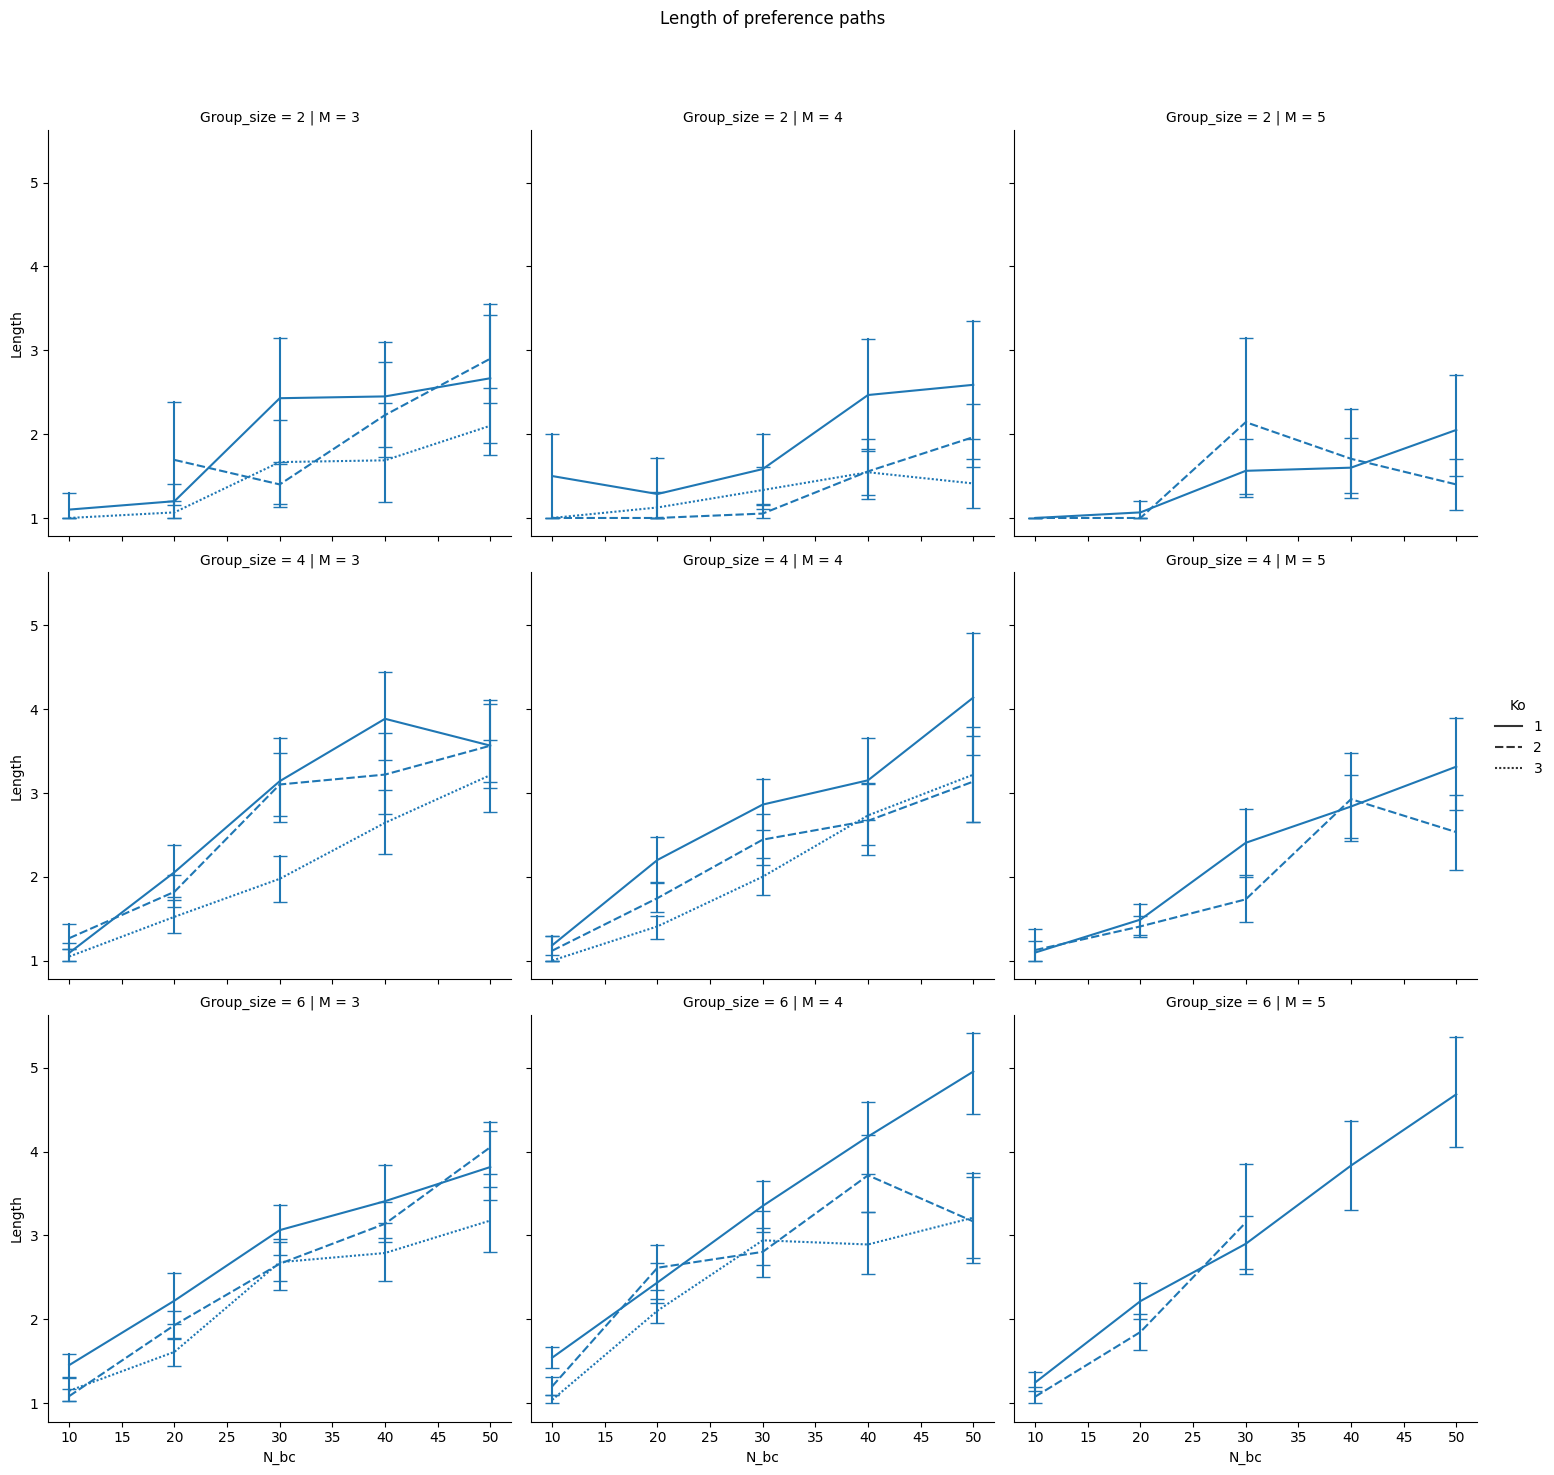

In [29]:
g = sns.relplot(
    df_path,
    x="N_bc",
    y=df_path.loc[df_path["Length"] > 0, "Length"],
    row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Length of preference paths")
g

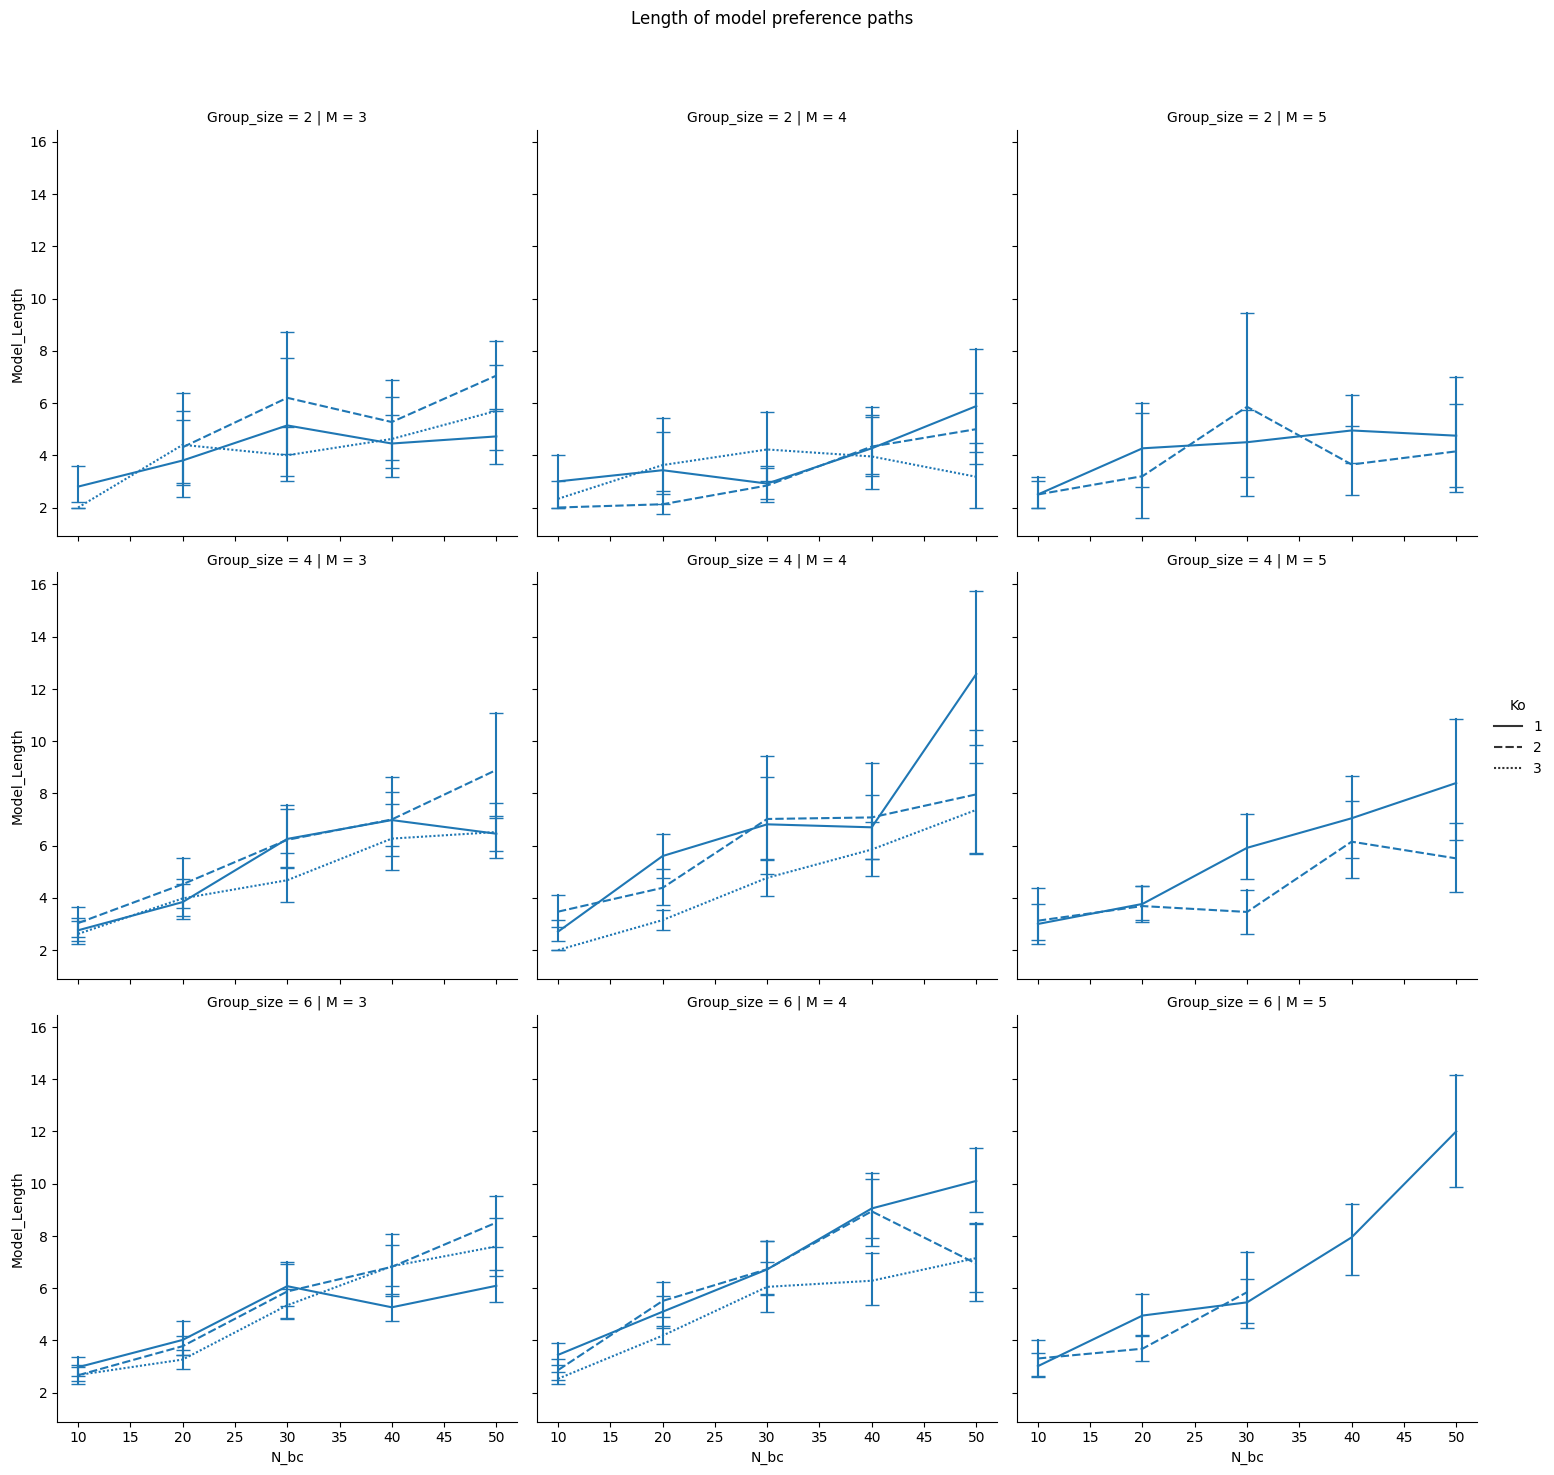

In [30]:
g = sns.relplot(
    df_path,
    x="N_bc",
    y=df_path.loc[df_path["Length"] > 0, "Model_Length"],
    row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Length of model preference paths")
g

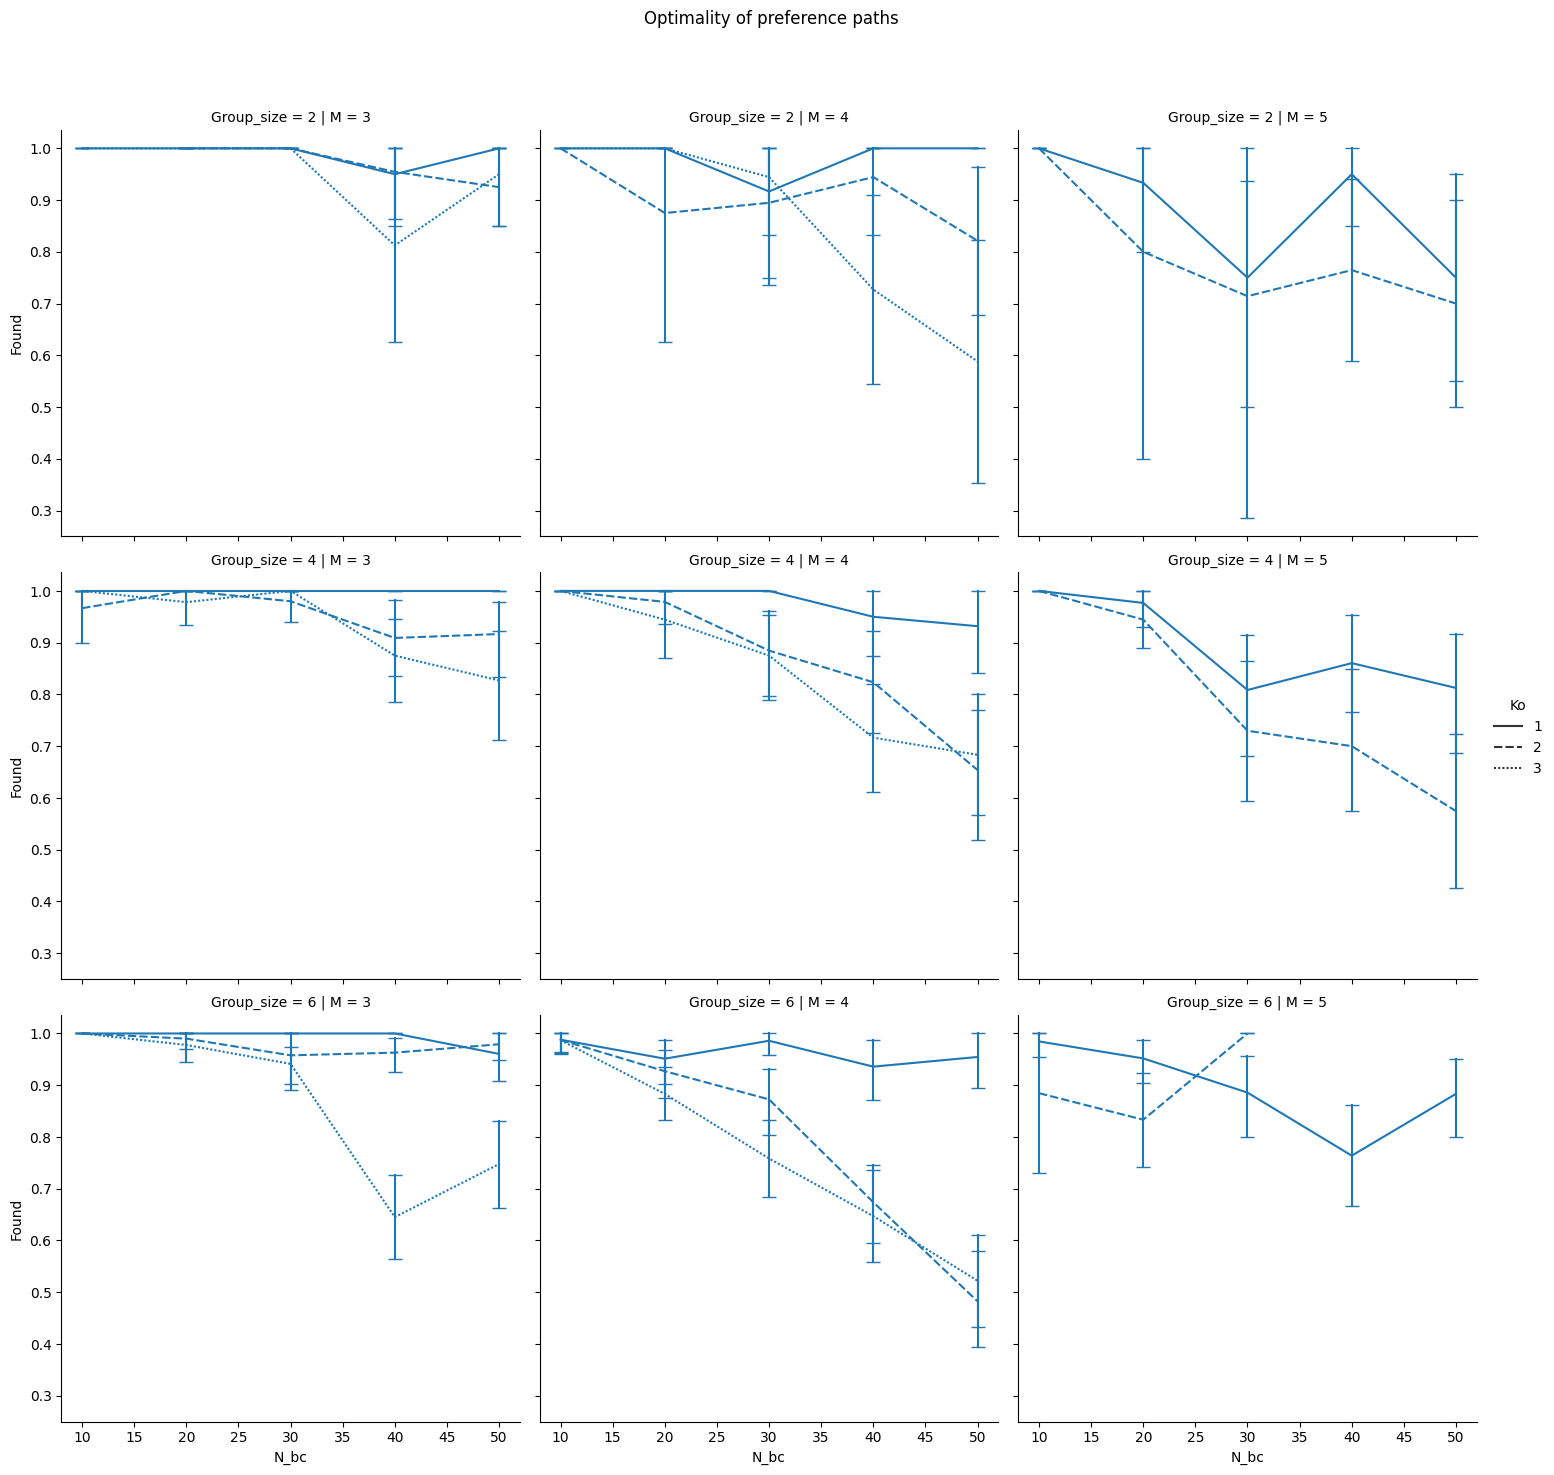

In [31]:
g = sns.relplot(
    df_path,
    x="N_bc",
    y=df_path.loc[df_path["Length"] > 0, "Found"],
    row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Optimality of preference paths")
g